In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# WiDS Week 4: Federated Learning with PyTorch - Plant Disease Classification
# Pure Week 4 Implementation - No Week 5 saving code

# ============================================
# SECTION 1: Install Required Libraries
# ============================================
# Run this in Kaggle first:
# !pip install flwr==1.11.1 torch torchvision -q

print("📦 Installation Commands:")
print("!pip install flwr==1.11.1 torch torchvision -q")

📦 Installation Commands:
!pip install flwr==1.11.1 torch torchvision -q


In [3]:
!pip install flwr


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.1/727.1 kB 12.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 79.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 92.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 15.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: pathspec
    Found existing installation: pathspec 1.0.3
    Uninstalling pathspec-1.0.3:
      Successfully uninstalled pathspec-1.0.3
  Attempting uninstall: grpcio
    Found existing installation: grpcio 1.75.1
    Uninstalling 

In [8]:
# SECTION 2: Import Libraries
# ============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
from PIL import Image

# Flower for Federated Learning
import flwr as fl
from typing import Dict, List, Tuple

print("✅ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Flower version: {fl.__version__}")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")

# ============================================
# SECTION 3: Configuration
# ============================================

# Dataset path
DATA_PATH = '/kaggle/input/plantvillage-dataset/color'

# Image settings (same as Week 3)
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Federated Learning settings
NUM_CLIENTS = 3          # Split data among 3 "farmers"
NUM_ROUNDS = 8           # Communication rounds
LOCAL_EPOCHS = 2         # Training epochs per client per round
MAX_SAMPLES_PER_CLASS = 200  # Same as Week 3

print(f"\n📊 Federated Learning Configuration:")
print(f"   Number of clients: {NUM_CLIENTS}")
print(f"   Communication rounds: {NUM_ROUNDS}")
print(f"   Local epochs per round: {LOCAL_EPOCHS}")
print(f"   Image size: {IMG_SIZE}")
print(f"   Max samples per class: {MAX_SAMPLES_PER_CLASS}")

✅ All libraries imported successfully!
PyTorch version: 2.8.0+cu126
Flower version: 1.25.0
🖥️  Device: cuda

📊 Federated Learning Configuration:
   Number of clients: 3
   Communication rounds: 8
   Local epochs per round: 2
   Image size: (128, 128)
   Max samples per class: 200


In [14]:
# ============================================
# SECTION 4: Custom Dataset Class
# ============================================

class PlantDiseaseDataset(Dataset):
    """PyTorch Dataset for Plant Disease Images"""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [15]:
# ============================================
# SECTION 5: Data Transforms (Augmentation)
# ============================================

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(IMG_SIZE[0], scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

print("\n✅ Data transforms configured")

# ============================================
# SECTION 6: Load and Prepare Data
# ============================================

def load_data_centralized(data_path, max_samples_per_class):
    """Load all data with paths and labels"""
    print("\n" + "="*50)
    print("LOADING CENTRALIZED DATA")
    print("="*50)
    
    classes = sorted([d for d in os.listdir(data_path) 
                     if os.path.isdir(os.path.join(data_path, d))])
    
    all_image_paths = []
    all_labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(data_path, class_name)
        image_files = [f for f in os.listdir(class_path) 
                      if f.endswith(('.jpg', '.png', '.jpeg', '.JPG'))]
        
        image_files = image_files[:max_samples_per_class]
        
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            all_image_paths.append(img_path)
            all_labels.append(class_idx)
    
    print(f"✅ Loaded {len(all_image_paths)} images from {len(classes)} classes")
    
    return np.array(all_image_paths), np.array(all_labels), classes

# Load data
image_paths, labels, class_names = load_data_centralized(
    DATA_PATH, MAX_SAMPLES_PER_CLASS
)

NUM_CLASSES = len(class_names)
print(f"Number of classes: {NUM_CLASSES}")


✅ Data transforms configured

LOADING CENTRALIZED DATA
✅ Loaded 7552 images from 38 classes
Number of classes: 38


In [17]:
# ============================================
# SECTION 7: Create Federated Data Partitions
# ============================================

def create_federated_partitions(image_paths, labels, num_clients):
    """Split data into NUM_CLIENTS partitions (IID)"""
    print("\n" + "="*50)
    print("CREATING FEDERATED PARTITIONS")
    print("="*50)
    
    indices = np.random.permutation(len(image_paths))
    shuffled_paths = image_paths[indices]
    shuffled_labels = labels[indices]
    
    partition_size = len(image_paths) // num_clients
    
    client_data = []
    for i in range(num_clients):
        start_idx = i * partition_size
        end_idx = start_idx + partition_size if i < num_clients - 1 else len(image_paths)
        
        client_paths = shuffled_paths[start_idx:end_idx]
        client_labels = shuffled_labels[start_idx:end_idx]
        
        split_idx = int(0.8 * len(client_paths))
        
        client_data.append({
            'train_paths': client_paths[:split_idx],
            'train_labels': client_labels[:split_idx],
            'val_paths': client_paths[split_idx:],
            'val_labels': client_labels[split_idx:]
        })
        
        print(f"Client {i+1}: {len(client_paths[:split_idx])} train, "
              f"{len(client_paths[split_idx:])} val")
    
    print(f"\n✅ Created {num_clients} federated partitions (IID)")
    
    return client_data

federated_data = create_federated_partitions(image_paths, labels, NUM_CLIENTS)

# ============================================
# SECTION 8: Build PyTorch Model (MobileNetV2)
# ============================================

def create_model(num_classes):
    """MobileNetV2 with custom head"""
    model = models.mobilenet_v2(pretrained=True)
    
    # Freeze base layers
    for param in model.parameters():
        param.requires_grad = False
    
    # Replace classifier
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    
    return model

print("\n🏗️ Model: MobileNetV2 + Custom Head (Frozen Base)")

# ============================================
# SECTION 9: Training and Evaluation Functions
# ============================================

def train(model, trainloader, optimizer, criterion, epochs, device):
    """Train model"""
    model.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    accuracy = 100. * correct / total
    return running_loss / len(trainloader), accuracy

def test(model, testloader, criterion, device):
    """Evaluate model"""
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    accuracy = 100. * correct / total
    return test_loss / len(testloader), accuracy

# ============================================
# SECTION 10: Flower Client
# ============================================

class PlantDiseaseClient(fl.client.NumPyClient):
    """Flower Client for Federated Learning"""
    
    def __init__(self, client_id, client_data, num_classes):
        self.client_id = client_id
        self.num_classes = num_classes
        
        self.model = create_model(num_classes).to(device)
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        
        train_dataset = PlantDiseaseDataset(
            client_data['train_paths'],
            client_data['train_labels'],
            transform=train_transform
        )
        
        val_dataset = PlantDiseaseDataset(
            client_data['val_paths'],
            client_data['val_labels'],
            transform=val_transform
        )
        
        self.trainloader = DataLoader(
            train_dataset, batch_size=BATCH_SIZE, 
            shuffle=True, num_workers=2
        )
        
        self.valloader = DataLoader(
            val_dataset, batch_size=BATCH_SIZE, 
            shuffle=False, num_workers=2
        )
        
        print(f"Client {client_id}: Train={len(train_dataset)}, Val={len(val_dataset)}")
    
    def get_parameters(self, config):
        """Return model parameters"""
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]
    
    def set_parameters(self, parameters):
        """Set model parameters"""
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=True)
    
    def fit(self, parameters, config):
        """Train locally"""
        self.set_parameters(parameters)
        
        train_loss, train_acc = train(
            self.model, self.trainloader, self.optimizer,
            self.criterion, LOCAL_EPOCHS, device
        )
        
        print(f"  Client {self.client_id} | Train Loss: {train_loss:.4f}, "
              f"Train Acc: {train_acc:.2f}%")
        
        return self.get_parameters(config={}), len(self.trainloader.dataset), {}
    
    def evaluate(self, parameters, config):
        """Evaluate model"""
        self.set_parameters(parameters)
        
        val_loss, val_acc = test(
            self.model, self.valloader, self.criterion, device
        )
        
        return float(val_loss), len(self.valloader.dataset), {"accuracy": float(val_acc)}


CREATING FEDERATED PARTITIONS
Client 1: 2013 train, 504 val
Client 2: 2013 train, 504 val
Client 3: 2014 train, 504 val

✅ Created 3 federated partitions (IID)

🏗️ Model: MobileNetV2 + Custom Head (Frozen Base)


In [18]:
# ============================================
# SECTION 11: Federated Averaging
# ============================================

def aggregate_weights(results):
    """Implement FedAvg"""
    total_examples = sum([num_examples for _, num_examples, _ in results])
    
    weighted_weights = []
    
    for layer_idx in range(len(results[0][0])):
        layer_sum = None
        
        for weights, num_examples, _ in results:
            weight = weights[layer_idx] * (num_examples / total_examples)
            
            if layer_sum is None:
                layer_sum = weight
            else:
                layer_sum += weight
        
        weighted_weights.append(layer_sum)
    
    return weighted_weights

def aggregate_metrics(results):
    """Aggregate metrics"""
    total_examples = sum([num_examples for _, num_examples, _ in results])
    
    weighted_acc = sum([
        (num_examples / total_examples) * metrics["accuracy"]
        for _, num_examples, metrics in results
    ])
    
    return weighted_acc

# ============================================
# SECTION 12: Run Federated Learning
# ============================================

print("\n" + "="*50)
print("🚀 STARTING FEDERATED LEARNING")
print("="*50)
print(f"\nConfiguration:")
print(f"  • {NUM_CLIENTS} clients (simulated farmers)")
print(f"  • {NUM_ROUNDS} communication rounds")
print(f"  • {LOCAL_EPOCHS} local epochs per round")
print(f"\nFederated Learning: Data stays on each client!")
print(f"Only model updates are shared.\n")

# Initialize global model
global_model = create_model(NUM_CLASSES).to(device)
global_params = [val.cpu().numpy() for _, val in global_model.state_dict().items()]

# Initialize clients
clients = [
    PlantDiseaseClient(i, federated_data[i], NUM_CLASSES)
    for i in range(NUM_CLIENTS)
]

# Storage for metrics
round_accuracies = []

print("="*50)

# Federated Learning Loop
for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\n🔄 Round {round_num}/{NUM_ROUNDS}")
    print("-" * 50)
    
    fit_results = []
    eval_results = []
    
    # Each client trains
    for client_id, client in enumerate(clients):
        updated_weights, num_examples, metrics = client.fit(global_params, {})
        fit_results.append((updated_weights, num_examples, metrics))
        
        loss, num_val, val_metrics = client.evaluate(updated_weights, {})
        eval_results.append((loss, num_val, val_metrics))
        
        print(f"    Client {client_id} Val Acc: {val_metrics['accuracy']:.2f}%")
    
    # Federated Averaging
    print("\n  🔀 Aggregating client updates (FedAvg)...")
    global_params = aggregate_weights(fit_results)
    
    # Update global model
    params_dict = zip(global_model.state_dict().keys(), global_params)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    global_model.load_state_dict(state_dict, strict=True)
    
    # Aggregate metrics
    global_accuracy = aggregate_metrics(eval_results)
    round_accuracies.append(global_accuracy)
    
    print(f"  📊 Global Model Accuracy: {global_accuracy:.2f}%")

print("\n" + "="*50)
print("✅ Federated Learning Complete!")
print("="*50)

# ============================================
# SECTION 13: Results Analysis
# ============================================

print("\n" + "="*50)
print("📊 FEDERATED LEARNING RESULTS")
print("="*50)

final_accuracy = round_accuracies[-1]

print(f"\n🎯 Final Results:")
print(f"   Week 3 Centralized Accuracy: 83.2%")
print(f"   Week 4 Federated Accuracy:   {final_accuracy:.2f}%")

accuracy_drop = 83.2 - final_accuracy
print(f"\n📉 Privacy Tax: {accuracy_drop:.2f}%")

if final_accuracy >= 80:
    print("\n✅ SUCCESS! Accuracy ≥ 80%")
    print("   The federated model is deployment-ready!")
elif final_accuracy >= 75:
    print("\n⚠️ ACCEPTABLE: Accuracy 75-80%")
    print("   Consider: More rounds or more local epochs")
else:
    print("\n❌ NEEDS IMPROVEMENT: Accuracy < 75%")
    print("   Try: Increase NUM_ROUNDS to 10-15 or LOCAL_EPOCHS to 3-5")



🚀 STARTING FEDERATED LEARNING

Configuration:
  • 3 clients (simulated farmers)
  • 8 communication rounds
  • 2 local epochs per round

Federated Learning: Data stays on each client!
Only model updates are shared.

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 108MB/s] 


Client 0: Train=2013, Val=504
Client 1: Train=2013, Val=504
Client 2: Train=2014, Val=504

🔄 Round 1/8
--------------------------------------------------
  Client 0 | Train Loss: 1.5688, Train Acc: 56.28%
    Client 0 Val Acc: 68.65%
  Client 1 | Train Loss: 1.6350, Train Acc: 53.75%
    Client 1 Val Acc: 72.02%
  Client 2 | Train Loss: 1.6005, Train Acc: 54.87%
    Client 2 Val Acc: 69.64%

  🔀 Aggregating client updates (FedAvg)...
  📊 Global Model Accuracy: 70.11%

🔄 Round 2/8
--------------------------------------------------
  Client 0 | Train Loss: 1.0404, Train Acc: 68.85%
    Client 0 Val Acc: 75.79%
  Client 1 | Train Loss: 1.0656, Train Acc: 68.01%
    Client 1 Val Acc: 76.79%
  Client 2 | Train Loss: 1.0424, Train Acc: 68.22%
    Client 2 Val Acc: 76.19%

  🔀 Aggregating client updates (FedAvg)...
  📊 Global Model Accuracy: 76.26%

🔄 Round 3/8
--------------------------------------------------
  Client 0 | Train Loss: 0.9015, Train Acc: 72.58%
    Client 0 Val Acc: 76.98%
  

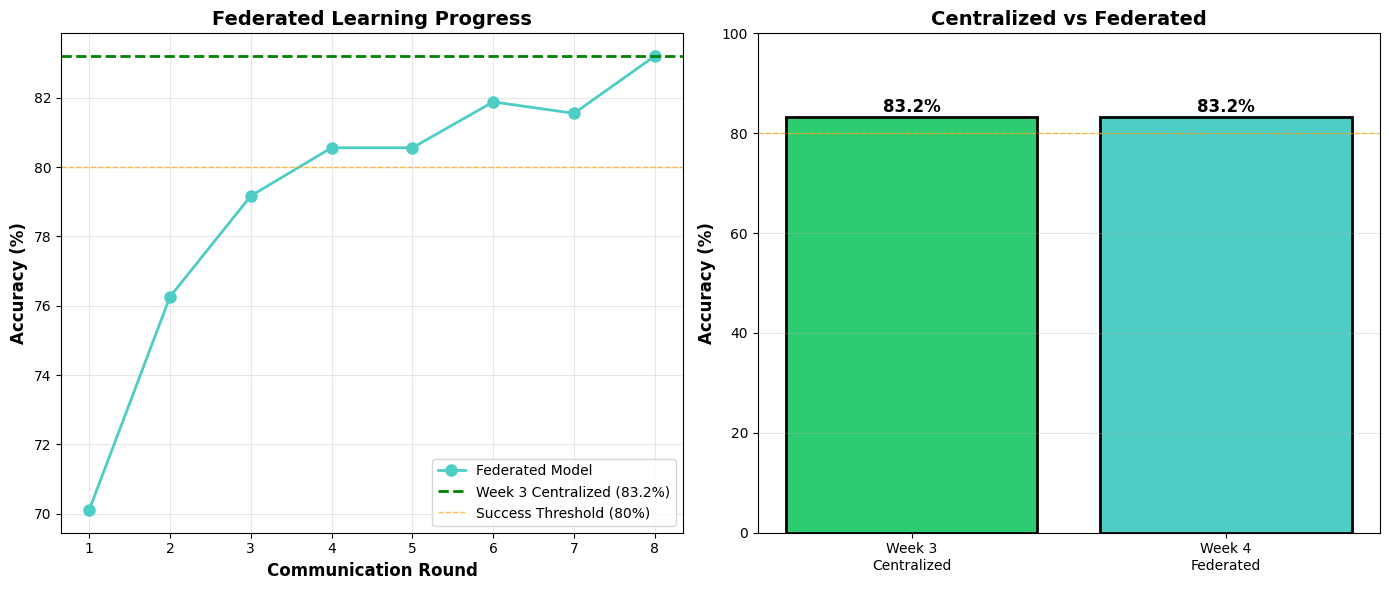


📈 Round-by-Round Progress:
Round      Accuracy (%)    Improvement    
--------------------------------------------------
1          70.11           +0.00%
2          76.26           +6.15%
3          79.17           +2.91%
4          80.56           +1.39%
5          80.56           +0.00%
6          81.88           +1.32%
7          81.55           -0.33%
8          83.20           +1.65%

💡 KEY LEARNINGS

1️⃣ THE FEDERATED TRADE-OFF:
   • Centralized: 83.2% (all data together)
   • Federated: 83.20% (data distributed)
   • Privacy Tax: -0.00%

2️⃣ WHY ACCURACY DROPS:
   • Each client sees only 1/3 of data
   • Local updates are noisier
   • Averaging smooths out specialized knowledge

3️⃣ WHEN TO USE FEDERATED LEARNING:
   • Healthcare: Patient data can't leave hospitals
   • Finance: Banks can't share customer data
   • Agriculture: Farms want privacy
   • Mobile: Train on-device without uploading data

✅ WEEK 4 COMPLETE!


In [19]:
# ============================================
# SECTION 14: Visualize Results
# ============================================

rounds = list(range(1, len(round_accuracies) + 1))

plt.figure(figsize=(14, 6))

# Plot 1: Training progress
plt.subplot(1, 2, 1)
plt.plot(rounds, round_accuracies, marker='o', linewidth=2, 
         markersize=8, color='#4ecdc4', label='Federated Model')
plt.axhline(y=83.2, color='green', linestyle='--', 
            linewidth=2, label='Week 3 Centralized (83.2%)')
plt.axhline(y=80, color='orange', linestyle='--', 
            linewidth=1, alpha=0.7, label='Success Threshold (80%)')
plt.xlabel('Communication Round', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Federated Learning Progress', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Comparison
plt.subplot(1, 2, 2)
models = ['Week 3\nCentralized', 'Week 4\nFederated']
accs = [83.2, final_accuracy]
colors = ['#2ecc71', '#4ecdc4']
bars = plt.bar(models, accs, color=colors, edgecolor='black', linewidth=2)

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 1, 
            f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Centralized vs Federated', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.axhline(y=80, color='orange', linestyle='--', linewidth=1, alpha=0.7)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# SECTION 15: Progress Table
# ============================================

print("\n📈 Round-by-Round Progress:")
print("="*50)
print(f"{'Round':<10} {'Accuracy (%)':<15} {'Improvement':<15}")
print("-"*50)

for i, acc in enumerate(round_accuracies, 1):
    improvement = acc - round_accuracies[i-2] if i > 1 else 0
    print(f"{i:<10} {acc:<15.2f} {improvement:+.2f}%")

print("="*50)

# ============================================
# SECTION 16: Key Learnings
# ============================================

print("\n" + "="*50)
print("💡 KEY LEARNINGS")
print("="*50)

print("\n1️⃣ THE FEDERATED TRADE-OFF:")
print(f"   • Centralized: 83.2% (all data together)")
print(f"   • Federated: {final_accuracy:.2f}% (data distributed)")
print(f"   • Privacy Tax: {accuracy_drop:.2f}%")

print("\n2️⃣ WHY ACCURACY DROPS:")
print("   • Each client sees only 1/3 of data")
print("   • Local updates are noisier")
print("   • Averaging smooths out specialized knowledge")

print("\n3️⃣ WHEN TO USE FEDERATED LEARNING:")
print("   • Healthcare: Patient data can't leave hospitals")
print("   • Finance: Banks can't share customer data")
print("   • Agriculture: Farms want privacy")
print("   • Mobile: Train on-device without uploading data")

print("\n" + "="*50)
print("✅ WEEK 4 COMPLETE!")
print("="*50)